In [1]:
import numpy as np

# ----- Create Toy Data -----
np.random.seed(0)
X = np.linspace(0, 10, 50)
true_beta0 = 2
true_beta1 = 3
y = true_beta0 + true_beta1 * X + np.random.normal(0, 1, size=X.shape)

X_design = np.column_stack((np.ones_like(X), X))   # [1, x]


# ----- MSE Function -----
def mse(beta):
    y_pred = X_design @ beta
    return np.mean((y_pred - y) ** 2)


# ----- RL Settings -----
beta = np.random.randn(2)          # initial coefficients [b0, b1]
step_size = 0.05
epsilon = 0.2                      # exploration rate
episodes = 3000

for ep in range(episodes):

    # Current MSE
    current_mse = mse(beta)

    # Exploration: try random nudges
    if np.random.rand() < epsilon:
        action = np.random.randn(2) * step_size
    else:
        # Exploit: try nudges in positive & negative directions, pick best
        candidates = []
        for direction in [np.array([1, 0]), np.array([-1, 0]),
                          np.array([0, 1]), np.array([0, -1])]:
            new_beta = beta + direction * step_size
            candidates.append((mse(new_beta), new_beta))

        best_mse, best_beta = min(candidates, key=lambda x: x[0])
        action = best_beta - beta

    # Apply action
    new_beta = beta + action

    # Reward = negative MSE
    reward = -mse(new_beta)

    # Accept change if reward improves
    if reward > -current_mse:
        beta = new_beta

# ----- Results -----
print("Learned beta:", beta)
print("True beta:   ", [true_beta0, true_beta1])
print("Final MSE:   ", mse(beta))

Learned beta: [2.83810403 2.86145524]
True beta:    [2, 3]
Final MSE:    1.0940501886505576


Learned beta: [2.83810403 2.86145524]
Final MSE: 1.0940501886505576


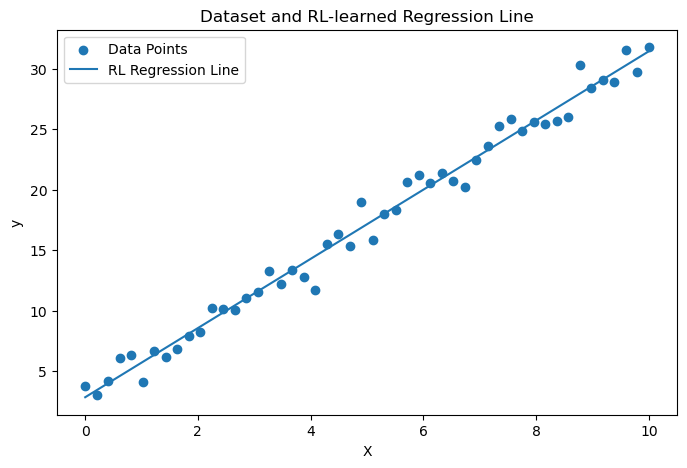

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Create Toy Data -----
np.random.seed(0)
X = np.linspace(0, 10, 50)
true_beta0 = 2
true_beta1 = 3
y = true_beta0 + true_beta1 * X + np.random.normal(0, 1, size=X.shape)

X_design = np.column_stack((np.ones_like(X), X))   # [1, x]


# ----- MSE Function -----
def mse(beta):
    y_pred = X_design @ beta
    return np.mean((y_pred - y) ** 2)


# ----- RL Settings -----
beta = np.random.randn(2)          # initial coefficients [b0, b1]
step_size = 0.05
epsilon = 0.2                      # exploration rate
episodes = 3000

for ep in range(episodes):

    # Current MSE
    current_mse = mse(beta)

    # Exploration: try random nudges
    if np.random.rand() < epsilon:
        action = np.random.randn(2) * step_size
    else:
        # Exploit: try nudges in positive & negative directions, pick best
        candidates = []
        for direction in [np.array([1, 0]), np.array([-1, 0]),
                          np.array([0, 1]), np.array([0, -1])]:
            new_beta = beta + direction * step_size
            candidates.append((mse(new_beta), new_beta))

        best_mse, best_beta = min(candidates, key=lambda x: x[0])
        action = best_beta - beta

    # Apply action
    new_beta = beta + action

    # Reward = negative MSE
    reward = -mse(new_beta)

    # Accept change if reward improves
    if reward > -current_mse:
        beta = new_beta

# Final prediction
y_pred = X_design @ beta

print("Learned beta:", beta)
print("Final MSE:", mse(beta))


# ----- Plot -----
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Data Points")
plt.plot(X, y_pred, label="RL Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dataset and RL-learned Regression Line")
plt.legend()
plt.show()

=== RL Learned Coefficients ===
[2.83810403 2.86145524]
RL MSE: 1.0940501886505576 

=== OLS Coefficients ===
[2.84637052 2.85883775]
OLS MSE: 1.09396752292814


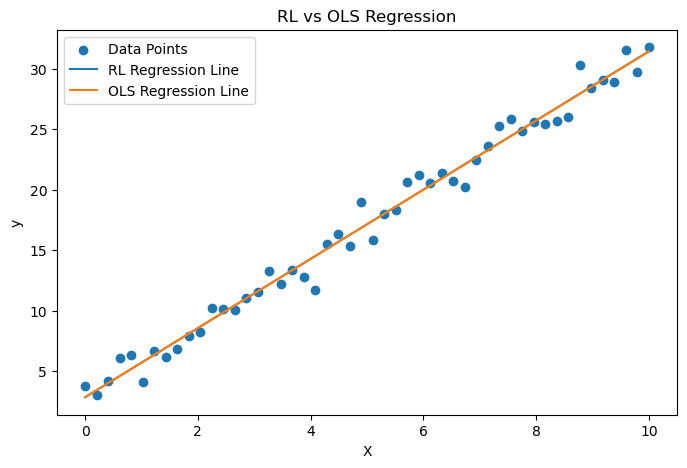

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Create Toy Data -----
np.random.seed(0)
X = np.linspace(0, 10, 50)
true_beta0 = 2
true_beta1 = 3
y = true_beta0 + true_beta1 * X + np.random.normal(0, 1, size=X.shape)

X_design = np.column_stack((np.ones_like(X), X))   # [1, x]


# ----- MSE Function -----
def mse(beta):
    y_pred = X_design @ beta
    return np.mean((y_pred - y) ** 2)


# ----- RL Settings -----
beta_rl = np.random.randn(2)          # initial [β0, β1]
step_size = 0.05
epsilon = 0.2                         # exploration rate
episodes = 3000

for ep in range(episodes):

    current_mse = mse(beta_rl)

    # Exploration: random movement
    if np.random.rand() < epsilon:
        action = np.random.randn(2) * step_size
    else:
        # Exploitation: try best of 4 directions
        candidates = []
        for direction in [np.array([1, 0]), np.array([-1, 0]),
                          np.array([0, 1]), np.array([0, -1])]:
            new_beta = beta_rl + direction * step_size
            candidates.append((mse(new_beta), new_beta))

        best_mse, best_beta = min(candidates, key=lambda x: x[0])
        action = best_beta - beta_rl

    new_beta = beta_rl + action
    reward = -mse(new_beta)

    # Accept if improvement
    if reward > -current_mse:
        beta_rl = new_beta

y_pred_rl = X_design @ beta_rl


# ----- OLS (using pseudoinverse) -----
beta_ols = np.linalg.pinv(X_design) @ y
y_pred_ols = X_design @ beta_ols


# ----- Print Results -----
print("=== RL Learned Coefficients ===")
print(beta_rl)
print("RL MSE:", mse(beta_rl), "\n")

print("=== OLS Coefficients ===")
print(beta_ols)
print("OLS MSE:", mse(beta_ols))


# ----- Plot -----
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Data Points")
plt.plot(X, y_pred_rl, label="RL Regression Line")
plt.plot(X, y_pred_ols, label="OLS Regression Line")
plt.xlabel("X")
plt.ylabel("y")
plt.title("RL vs OLS Regression")
plt.legend()
plt.show()
